Melakukan Feature Engineering V2 (Horizon 7 Hari)...

MAPE Model(Jawa Timur): 1.0934%


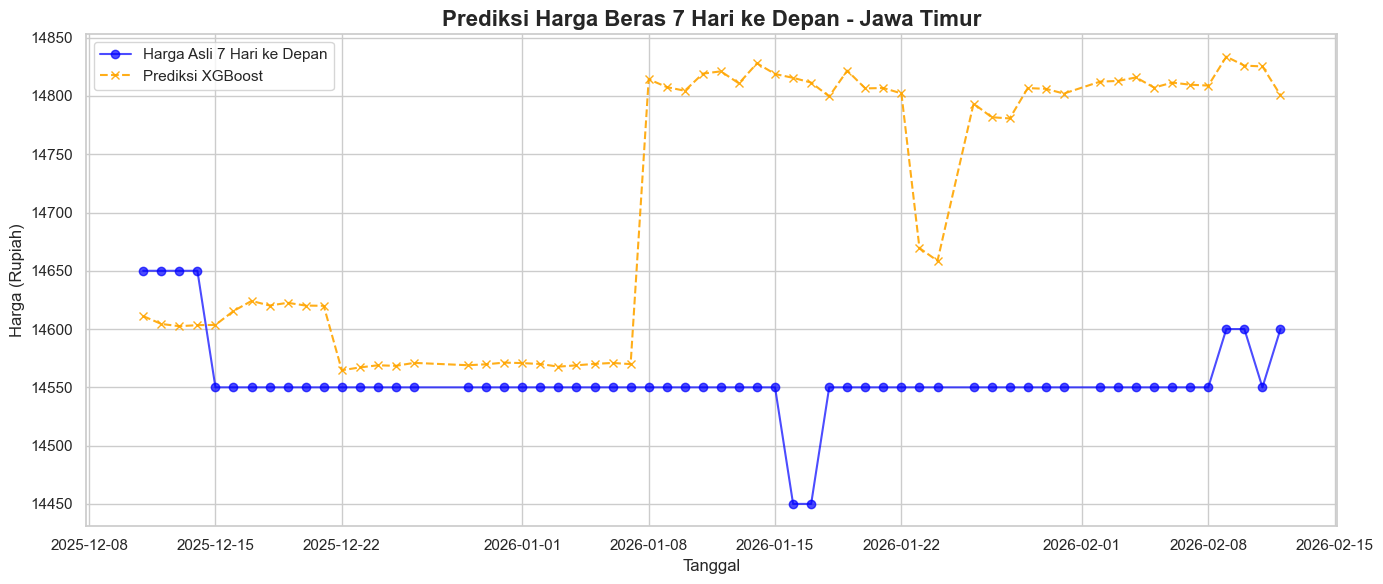

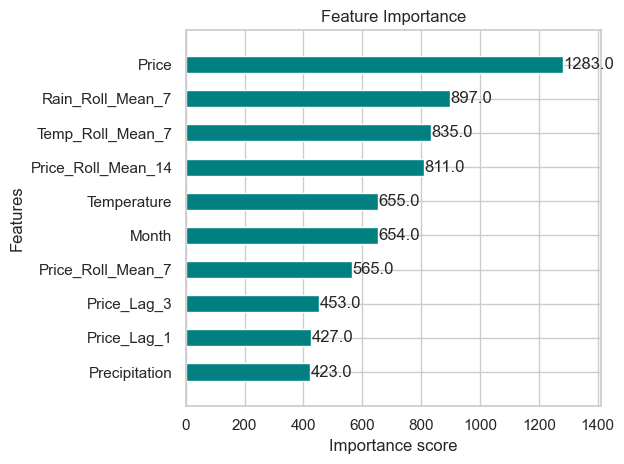

In [ ]:
# 5. Pengembangan Model

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 5.1. Memuat Dataset "dataset_lengkap.csv"
df = pd.read_csv('../data/processed/dataset_lengkap.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 5.2. Fokus pada satu provinsi, Jawa Timur
provinsi_target = 'Jawa Timur'
df_model = df[df['Province_Name'] == provinsi_target].copy()
df_model = df_model.sort_values('Date').reset_index(drop=True)


# 5.3. FEATURE ENGINEERING
print("Melakukan Feature Engineering V2 (Horizon 7 Hari)...")

df_model['Target_Price_7d'] = df_model['Price'].shift(-7)

df_model['DayOfWeek'] = df_model['Date'].dt.dayofweek
df_model['Month'] = df_model['Date'].dt.month

df_model['Price_Lag_1'] = df_model['Price'].shift(1)
df_model['Price_Lag_3'] = df_model['Price'].shift(3)
df_model['Price_Roll_Mean_7'] = df_model['Price'].rolling(window=7).mean()
df_model['Price_Roll_Mean_14'] = df_model['Price'].rolling(window=14).mean()

df_model['Rain_Roll_Mean_7'] = df_model['Precipitation'].rolling(window=7).mean()
df_model['Temp_Roll_Mean_7'] = df_model['Temperature'].rolling(window=7).mean()

df_model = df_model.dropna().reset_index(drop=True)

# 5.4. PEMBAGIAN DATA (TRAIN & TEST)
test_size = 60 # Uji pada 60 hari terakhir yang terekam
train_data = df_model.iloc[:-test_size]
test_data = df_model.iloc[-test_size:]

# Tentukan Fitur (X) dan Target (y)
features = [
    'Price', 'Price_Lag_1', 'Price_Lag_3', 'Price_Roll_Mean_7', 'Price_Roll_Mean_14',
    'Temperature', 'Precipitation', 'Rain_Roll_Mean_7', 'Temp_Roll_Mean_7',
    'DayOfWeek', 'Month'
]
target = 'Target_Price_7d'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# 5.5. PEMODELAN XGBOOST
model = xgb.XGBRegressor(
    n_estimators=200, 
    learning_rate=0.03, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

# 5.6. PREDIKSI & EVALUASI
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"\nMAPE Model({provinsi_target}): {mape:.4f}%")

# 5.7. VISUALISASI HASIL PREDIKSI
plt.figure(figsize=(14, 6))
tanggal_prediksi = test_data['Date'] + pd.Timedelta(days=7)

plt.plot(tanggal_prediksi, y_test, label='Harga Asli 7 Hari ke Depan', color='blue', marker='o', alpha=0.7)
plt.plot(tanggal_prediksi, y_pred, label='Prediksi XGBoost', color='orange', linestyle='--', marker='x', alpha=0.9)

plt.title(f'Prediksi Harga Beras 7 Hari ke Depan - {provinsi_target}', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rupiah)')
plt.legend()
plt.tight_layout()
plt.savefig(f'../laporan/prediksi_xgboost_{provinsi_target.replace(" ", "_")}.png', dpi=300)
plt.show()

# 5.8. FEATURE IMPORTANCE
xgb.plot_importance(model, importance_type='weight', max_num_features=10, height=0.5, color='teal')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig(f'../laporan/feature_importance.png', dpi=300)
plt.show()

Melakukan Preprocessing (Imputasi & Normalisasi)...
Melakukan Feature Engineering V2 (Horizon 7 Hari)...

Hasil Evaluasi Model (Jawa Timur):
MAPE : 1.0266%
MAE  : 149.35
RMSE : 186.26


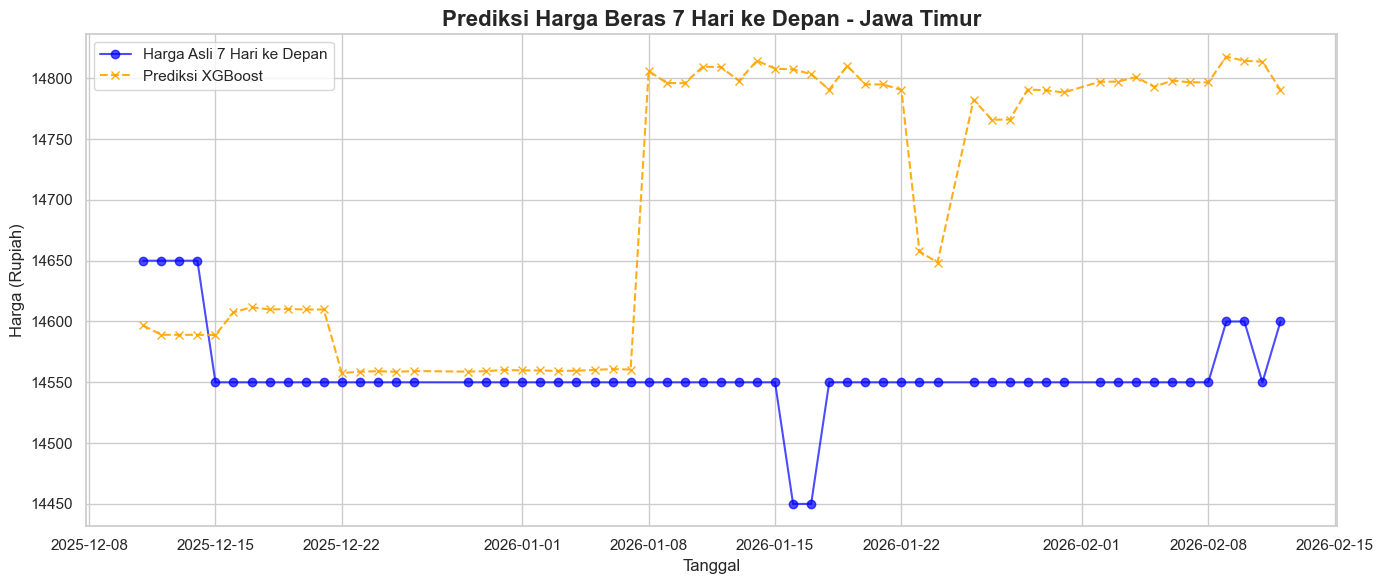

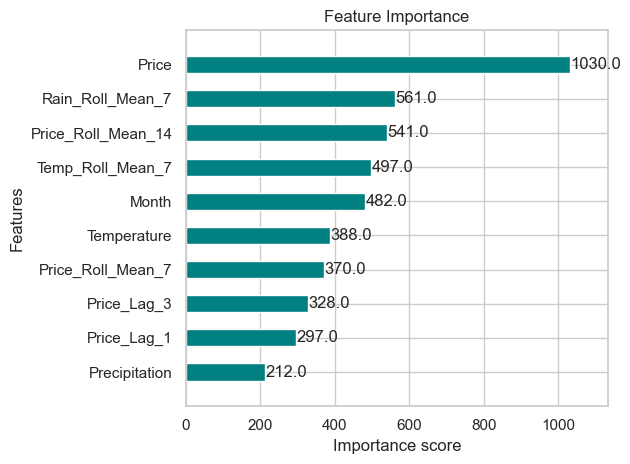

In [2]:
# 5. Pengembangan Model

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 5.1. Memuat Dataset "dataset_lengkap.csv"
df = pd.read_csv('../data/processed/dataset_lengkap.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 5.2. Fokus pada satu provinsi, Jawa Timur
provinsi_target = 'Jawa Timur'
df_model = df[df['Province_Name'] == provinsi_target].copy()
df_model = df_model.sort_values('Date').reset_index(drop=True)

# 5.2.1 PREPROCESSING (Sesuai Revisi)
print("Melakukan Preprocessing (Imputasi & Normalisasi)...")
# Mengisi missing value historis (jika ada) dengan metode Forward Fill
df_model[['Price', 'Temperature', 'Precipitation']] = df_model[['Price', 'Temperature', 'Precipitation']].ffill()

# Normalisasi data cuaca agar skalanya 0-1
scaler = MinMaxScaler()
df_model[['Temperature', 'Precipitation']] = scaler.fit_transform(df_model[['Temperature', 'Precipitation']])


# 5.3. FEATURE ENGINEERING
print("Melakukan Feature Engineering V2 (Horizon 7 Hari)...")

df_model['Target_Price_7d'] = df_model['Price'].shift(-7)

df_model['DayOfWeek'] = df_model['Date'].dt.dayofweek
df_model['Month'] = df_model['Date'].dt.month

df_model['Price_Lag_1'] = df_model['Price'].shift(1)
df_model['Price_Lag_3'] = df_model['Price'].shift(3)
df_model['Price_Roll_Mean_7'] = df_model['Price'].rolling(window=7).mean()
df_model['Price_Roll_Mean_14'] = df_model['Price'].rolling(window=14).mean()

df_model['Rain_Roll_Mean_7'] = df_model['Precipitation'].rolling(window=7).mean()
df_model['Temp_Roll_Mean_7'] = df_model['Temperature'].rolling(window=7).mean()

# Drop NaN akibat proses pergeseran (shift/rolling)
df_model = df_model.dropna().reset_index(drop=True)

# 5.4. PEMBAGIAN DATA (TRAIN & TEST)
test_size = 60 # Uji pada 60 hari terakhir yang terekam
train_data = df_model.iloc[:-test_size]
test_data = df_model.iloc[-test_size:]

# Tentukan Fitur (X) dan Target (y)
features = [
    'Price', 'Price_Lag_1', 'Price_Lag_3', 'Price_Roll_Mean_7', 'Price_Roll_Mean_14',
    'Temperature', 'Precipitation', 'Rain_Roll_Mean_7', 'Temp_Roll_Mean_7',
    'DayOfWeek', 'Month'
]
target = 'Target_Price_7d'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# 5.5. PEMODELAN XGBOOST
model = xgb.XGBRegressor(
    n_estimators=150, 
    learning_rate=0.03, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train)

# 5.6. PREDIKSI & EVALUASI
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nHasil Evaluasi Model ({provinsi_target}):")
print(f"MAPE : {mape:.4f}%")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# 5.7. VISUALISASI HASIL PREDIKSI
plt.figure(figsize=(14, 6))
tanggal_prediksi = test_data['Date'] + pd.Timedelta(days=7)

plt.plot(tanggal_prediksi, y_test, label='Harga Asli 7 Hari ke Depan', color='blue', marker='o', alpha=0.7)
plt.plot(tanggal_prediksi, y_pred, label='Prediksi XGBoost', color='orange', linestyle='--', marker='x', alpha=0.9)

plt.title(f'Prediksi Harga Beras 7 Hari ke Depan - {provinsi_target}', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rupiah)')
plt.legend()
plt.tight_layout()
plt.savefig(f'../laporan/prediksi_xgboost_{provinsi_target.replace(" ", "_")}.png', dpi=300)
plt.show()

# 5.8. FEATURE IMPORTANCE
xgb.plot_importance(model, importance_type='weight', max_num_features=10, height=0.5, color='teal')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig(f'../laporan/feature_importance.png', dpi=300)
plt.show()